In [18]:
import pandas as pd
from prophet import Prophet
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [19]:
data = pd.read_csv('/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/Type of analysis/Analisis temporal/merged files/csv/microsoft/microsoft_data.csv')

In [20]:
data

,Unnamed: 0,date,Price,revenue_musd,net_income_musd,total_assets_musd,total_liabilities_musd,share_holder_equity_musd,gdp_growth,interest_rate
0,0,2009-03-31,13.531229,13648.0,2977.0,68853.0,31910.0,36943.0,-3.23,0.15
1,1,2009-06-30,17.620026,13099.0,3045.0,77888.0,38330.0,39558.0,-3.98,0.16
2,2,2009-09-30,19.172707,12920.0,3574.0,81612.0,40400.0,41212.0,-3.13,0.12
3,3,2009-12-31,22.821438,19022.0,6662.0,82096.0,37813.0,44283.0,0.11,0.11
4,4,2010-03-31,22.032991,14503.0,4006.0,84910.0,39200.0,45710.0,1.75,0.20
...,...,...,...,...,...,...,...,...,...,...
61,61,2024-06-30,442.821350,64727.0,22036.0,512163.0,243686.0,268477.0,3.04,5.33
62,62,2024-09-30,427.093567,65585.0,24667.0,523013.0,235290.0,287723.0,2.72,4.83
63,63,2024-12-31,419.196533,69632.0,24108.0,533898.0,231203.0,302695.0,2.53,4.33
64,64,2025-03-31,374.087158,70066.0,25824.0,562624.0,240733.0,321891.0,1.99,4.33


In [21]:
# create column assets_liabilities_ratio
data['assets_liabilities_ratio'] = data['total_assets_musd'] / data['total_liabilities_musd']

# drop columns total_assets_musd total_liabilities_musd and other unnecessary columns
data = data.drop(columns=['total_assets_musd', 'total_liabilities_musd', 'Unnamed: 0'])

In [22]:
#1)rename date to ds and Price to y for prophet

data = data.rename(columns={"date": "ds", "Price": "y"})

data["ds"]= pd.to_datetime(data["ds"], format="%Y-%m-%d")

#reorder columns
data = data[["ds", "y", "revenue_musd", "net_income_musd", "assets_liabilities_ratio", "share_holder_equity_musd", "gdp_growth", "interest_rate"]]

#create backtesting data

data_bt = data.iloc[:-4]

data[40:]

,ds,y,revenue_musd,net_income_musd,assets_liabilities_ratio,share_holder_equity_musd,gdp_growth,interest_rate
40,2019-03-31,111.028870,30571.0,8809.0,1.563269,94864.0,1.93,2.42
41,2019-06-30,126.576942,33717.0,13187.0,1.555459,102330.0,2.24,2.40
42,2019-09-30,131.804962,33055.0,10678.0,1.613445,106061.0,2.80,1.83
43,2019-12-31,150.013428,36906.0,11649.0,1.637629,110109.0,3.35,1.55
44,2020-03-31,150.432755,35021.0,10752.0,1.669800,114501.0,1.28,0.05
45,2020-06-30,194.660019,38033.0,11202.0,1.646445,118304.0,-7.50,0.09
46,2020-09-30,201.669800,37154.0,13893.0,1.694740,123392.0,-1.41,0.09
47,2020-12-31,213.820297,43076.0,15463.0,1.748909,130236.0,-1.02,0.09
48,2021-03-31,227.176147,41706.0,15457.0,1.771359,134505.0,1.76,0.07
49,2021-06-30,261.628357,46152.0,16458.0,1.740327,141988.0,12.24,0.10


In [23]:
#2) Add a future base scenario so Proheet can make predictions

# ================== CONFIG ==================
FUTURE_PERIODS = 4    # nº de trimestres a predecir
FREQ = "Q"            # frecuencia trimestral
REG_COLS = ["revenue_musd", "net_income_musd", "assets_liabilities_ratio", "share_holder_equity_musd", "gdp_growth", "interest_rate"]

# ================== PREP ====================
df = data.copy()
#df = df.rename(columns={"DS": "ds"})   # Prophet requiere columnas: ds (datetime), y (target)
df["ds"] = pd.to_datetime(df["ds"], errors="coerce")

# Asegura que los regresores existan (si falta alguno, lo creamos como NaN)
for c in REG_COLS:
    if c not in df.columns:
        df[c] = np.nan

# Convierte gdp_growth a numérico si venía como texto/%
if df["gdp_growth"].dtype == "object":
    df["gdp_growth"] = (
        df["gdp_growth"].astype(str).str.replace("%", "", regex=False).str.replace(",", "", regex=False)
        .replace({"": np.nan}).astype(float)
    )

# Rellena huecos internos con forward-fill (opcional pero útil para entrenar)
df[REG_COLS] = df[REG_COLS].ffill()

# ================== ESCENARIO FUTURO ==================
# Calcula crecimiento medio trimestral para flows/equity
growth_rates = {}
for col in ["revenue_musd", "net_income_musd", "share_holder_equity_musd"]:  #Calculate growth rates and append to dictionary
    growth_rates[col] = df[col].pct_change().mean(skipna=True)

growth_rates["gdp_growth"]=df["gdp_growth"].mean() #Cause gdp_growth is already a growth rate just calculate the mean
growth_rates["interest_rate"]=df["interest_rate"].mean() #Cause interest_rate is already a rate just calculate the mean


# Último punto observado
last = df.sort_values("ds").iloc[-1]

# Fechas futuras
future_dates = pd.date_range(start=df["ds"].max(), periods=FUTURE_PERIODS+1, freq=FREQ)[1:]
future = pd.DataFrame({"ds": future_dates})

# Proyecta regresores (escenario baseline)
for col in ["revenue_musd", "net_income_musd", "share_holder_equity_musd"]:
    gr = 0.0 if np.isnan(growth_rates[col]) else growth_rates[col]
    future[col] = [last[col] * (1 + gr) ** i for i in range(1, FUTURE_PERIODS+1)]

# Mantén constantes estos regresores (o pon tu propio escenario)
future["assets_liabilities_ratio"] = last["assets_liabilities_ratio"]
# gdp_growth: mantener último valor (o define tu propio escenario macro)
future["gdp_growth"] = last["gdp_growth"]
# interest_rate: mantener último valor (o define tu propio escenario macro)
future["interest_rate"] = last["interest_rate"]

# Combina histórico (con y) y futuro (sin y)
hist = df[["ds", "y"] + REG_COLS].copy()
future_full = pd.concat([hist, future], ignore_index=True)


/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_10258/2203269307.py:42: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  future_dates = pd.date_range(start=df["ds"].max(), periods=FUTURE_PERIODS+1, freq=FREQ)[1:]


In [24]:
#2) Replicate the same for backtesting data

# ================== PREP ====================
df_bt = data_bt.copy()
#df = df.rename(columns={"DS": "ds"})   # Prophet requiere columnas: ds (datetime), y (target)
df_bt["ds"] = pd.to_datetime(df_bt["ds"], errors="coerce")

# Asegura que los regresores existan (si falta alguno, lo creamos como NaN)
for c in REG_COLS:
    if c not in df.columns:
        df_bt[c] = np.nan

# Convierte gdp_growth a numérico si venía como texto/%
if df_bt["gdp_growth"].dtype == "object":
    df_bt["gdp_growth"] = (
        df_bt["gdp_growth"].astype(str).str.replace("%", "", regex=False).str.replace(",", "", regex=False)
        .replace({"": np.nan}).astype(float)
    )

# Rellena huecos internos con forward-fill (opcional pero útil para entrenar)
df_bt[REG_COLS] = df_bt[REG_COLS].ffill()

# ================== ESCENARIO FUTURO ==================
# Calcula crecimiento medio trimestral para flows/equity
growth_rates_bt = {}
for col in ["revenue_musd", "net_income_musd", "share_holder_equity_musd"]:  #Calculate growth rates and append to dictionary
    growth_rates_bt[col] = df_bt[col].pct_change().mean(skipna=True)

growth_rates_bt["gdp_growth"]=df_bt["gdp_growth"].mean() #Cause gdp_growth is already a growth rate just calculate the mean
growth_rates_bt["interest_rate"]=df_bt["interest_rate"].mean() #Cause interest_rate is already a rate just calculate the mean


# Último punto observado
last_bt = df_bt.sort_values("ds").iloc[-1]

# Fechas futuras
future_dates_bt = pd.date_range(start=df_bt["ds"].max(), periods=FUTURE_PERIODS+1, freq=FREQ)[1:]
future_bt = pd.DataFrame({"ds": future_dates_bt})

# Proyecta regresores (escenario baseline)
for col in ["revenue_musd", "net_income_musd", "share_holder_equity_musd"]:
    gr_bt = 0.0 if np.isnan(growth_rates_bt[col]) else growth_rates_bt[col]
    future_bt[col] = [last_bt[col] * (1 + gr) ** i for i in range(1, FUTURE_PERIODS+1)]

# Mantén constantes estos regresores (o pon tu propio escenario)
future_bt["assets_liabilities_ratio"] = last_bt["assets_liabilities_ratio"]
# gdp_growth: mantener último valor (o define tu propio escenario macro)
future_bt["gdp_growth"] = last_bt["gdp_growth"]
# interest_rate: mantener último valor (o define tu propio escenario macro)
future_bt["interest_rate"] = last_bt["interest_rate"]

# Combina histórico (con y) y futuro (sin y)
hist_bt = df_bt[["ds", "y"] + REG_COLS].copy()
future_full_bt = pd.concat([hist_bt, future_bt], ignore_index=True)

/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_10258/1325257280.py:37: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  future_dates_bt = pd.date_range(start=df_bt["ds"].max(), periods=FUTURE_PERIODS+1, freq=FREQ)[1:]


In [25]:
growth_rates_bt

{'revenue_musd': np.float64(0.03450158082978596),
 'net_income_musd': np.float64(-0.26458597860477573),
 'share_holder_equity_musd': np.float64(0.034279341365833604),
 'gdp_growth': np.float64(2.0856451612903224),
 'interest_rate': np.float64(1.0941935483870966)}

In [26]:
#3) Initializa model and an train it

m=Prophet()

for col in REG_COLS:
    m.add_regressor(col)

#4) Fit and train with only historical data (with y)
train_df = future_full.dropna(subset=["y"]).copy()
m.fit(train_df)
                       

#5) Make predictions for the full dataset (historical + future)
predict_df = future_full[["ds"] + REG_COLS].copy()
forecast = m.predict(predict_df)

#6) Plot the results. Merge forecast with original data to compare
out = forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].merge(
    df[["ds","y"]], on="ds", how="left"
).sort_values("ds")

print(out.tail(12))



16:17:32 - cmdstanpy - INFO - Chain [1] start processing
16:17:32 - cmdstanpy - INFO - Chain [1] done processing


           ds        yhat  yhat_lower  yhat_upper           y
58 2023-09-30  315.634254  291.500356  339.203126  311.062347
59 2023-12-31  350.504397  326.332181  373.651618  371.209137
60 2024-03-31  382.580117  359.170241  407.908648  416.083160
61 2024-06-30  400.464956  378.289836  425.115721  442.821350
62 2024-09-30  424.327855  402.059802  447.580670  427.093567
63 2024-12-31  411.977013  388.247721  435.710693  419.196533
64 2025-03-31  440.344567  416.358576  464.052127  374.087158
65 2025-06-30  498.412755  473.901616  522.000156  496.593658
66 2025-09-30  537.184080  511.075339  559.855247         NaN
67 2025-12-31  516.983318  492.082960  541.846923         NaN
68 2026-03-31  573.992900  549.439892  597.822113         NaN
69 2026-06-30  587.225799  563.045837  610.256321         NaN


In [27]:
#3) Replicate the same for backtesting data

m_bt=Prophet()

for col in REG_COLS:
    m_bt.add_regressor(col)

#4) Fit and train with only historical data (with y)
train_df_bt = future_full_bt.dropna(subset=["y"]).copy()
m_bt.fit(train_df_bt)
                       

#5) Make predictions for the full dataset (historical + future)
predict_df_bt = future_full_bt[["ds"] + REG_COLS].copy()
forecast_bt = m_bt.predict(predict_df_bt)

#6) Plot the results. Merge forecast with original data to compare
out_bt = forecast_bt[["ds", "yhat", "yhat_lower", "yhat_upper"]].merge(
    df_bt[["ds","y"]], on="ds", how="left"
).sort_values("ds")

print(out_bt.tail(12))

16:17:32 - cmdstanpy - INFO - Chain [1] start processing
16:17:32 - cmdstanpy - INFO - Chain [1] done processing


           ds        yhat  yhat_lower  yhat_upper           y
54 2022-09-30  263.751332  246.772948  280.168686  227.246918
55 2022-12-31  255.514294  238.793567  272.072237  234.658417
56 2023-03-31  282.241778  264.370142  299.270947  282.801575
57 2023-06-30  311.197451  295.615050  326.870393  334.775482
58 2023-09-30  328.130068  310.613904  342.830013  311.062347
59 2023-12-31  371.549322  354.755459  389.417948  371.209137
60 2024-03-31  405.205958  387.617377  420.948521  416.083160
61 2024-06-30  433.066776  415.995222  449.576520  442.821350
62 2024-09-30  472.241351  455.571382  490.210985         NaN
63 2024-12-31  475.055189  458.758674  491.147577         NaN
64 2025-03-31  521.342556  504.261616  538.417873         NaN
65 2025-06-30  534.181438  517.777672  550.439310         NaN


In [28]:
#4) Merge prediction with actual y

# Keep all rows (historical + future)
results = forecast[["ds","yhat","yhat_lower","yhat_upper"]].merge(
    data.rename(columns={"DS":"ds"})[["ds","y"]],
    on="ds", how="left"
)

# Flag which rows are future
results["is_future"] = results["y"].isna()

# Compute metrics only on historical rows
mask = ~results["is_future"]
mae = mean_absolute_error(results.loc[mask,"y"], results.loc[mask,"yhat"])
rmse = mean_squared_error(results.loc[mask,"y"], results.loc[mask,"yhat"])
r2   = r2_score(results.loc[mask,"y"], results.loc[mask,"yhat"])

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

# Show last 12 rows (will include future with y = NaN)
print(results.tail(12))

MAE: 13.26533756028527
RMSE: 357.2982503799076
R²: 0.980592299907256
           ds        yhat  yhat_lower  yhat_upper           y  is_future
58 2023-09-30  315.634254  291.500356  339.203126  311.062347      False
59 2023-12-31  350.504397  326.332181  373.651618  371.209137      False
60 2024-03-31  382.580117  359.170241  407.908648  416.083160      False
61 2024-06-30  400.464956  378.289836  425.115721  442.821350      False
62 2024-09-30  424.327855  402.059802  447.580670  427.093567      False
63 2024-12-31  411.977013  388.247721  435.710693  419.196533      False
64 2025-03-31  440.344567  416.358576  464.052127  374.087158      False
65 2025-06-30  498.412755  473.901616  522.000156  496.593658      False
66 2025-09-30  537.184080  511.075339  559.855247         NaN       True
67 2025-12-31  516.983318  492.082960  541.846923         NaN       True
68 2026-03-31  573.992900  549.439892  597.822113         NaN       True
69 2026-06-30  587.225799  563.045837  610.256321      

In [29]:
#4) Replicate the same for backtesting data

# Keep all rows (historical + future)
results_bt = forecast_bt[["ds","yhat","yhat_lower","yhat_upper"]].merge(
    data_bt.rename(columns={"DS":"ds"})[["ds","y"]],
    on="ds", how="left"
)

# Flag which rows are future
results_bt["is_future"] = results_bt["y"].isna()

# Compute metrics only on historical rows
mask_bt = ~results_bt["is_future"]
mae_bt = mean_absolute_error(results_bt.loc[mask_bt,"y"], results_bt.loc[mask_bt,"yhat"])
rmse_bt = mean_squared_error(results_bt.loc[mask_bt,"y"], results_bt.loc[mask_bt,"yhat"])
r2_bt   = r2_score(results_bt.loc[mask_bt,"y"], results_bt.loc[mask_bt,"yhat"])

print("MAE:", mae_bt)
print("RMSE:", rmse_bt)
print("R²:", r2_bt)

# Show last 12 rows (will include future with y = NaN)
print(results_bt.tail(12))

MAE: 9.966442602968531
RMSE: 170.24197634866084
R²: 0.9873815066369503
           ds        yhat  yhat_lower  yhat_upper           y  is_future
54 2022-09-30  263.751332  246.772948  280.168686  227.246918      False
55 2022-12-31  255.514294  238.793567  272.072237  234.658417      False
56 2023-03-31  282.241778  264.370142  299.270947  282.801575      False
57 2023-06-30  311.197451  295.615050  326.870393  334.775482      False
58 2023-09-30  328.130068  310.613904  342.830013  311.062347      False
59 2023-12-31  371.549322  354.755459  389.417948  371.209137      False
60 2024-03-31  405.205958  387.617377  420.948521  416.083160      False
61 2024-06-30  433.066776  415.995222  449.576520  442.821350      False
62 2024-09-30  472.241351  455.571382  490.210985         NaN       True
63 2024-12-31  475.055189  458.758674  491.147577         NaN       True
64 2025-03-31  521.342556  504.261616  538.417873         NaN       True
65 2025-06-30  534.181438  517.777672  550.439310    

In [30]:
#5) Compare the actuall y with the yhat prediction for the backtesting period
comparison = data[["ds", "y"]]
comparison_bt = results_bt[["ds", "yhat"]]
comparison = comparison.merge(comparison_bt, on="ds", how="inner")
comparison["absolute error"] = (comparison["y"] - comparison["yhat"]).abs()
comparison["relative error"] = ((comparison["absolute error"] / comparison["y"])*100).round(1).astype(str)+"%"
print(comparison.tail(12))

           ds           y        yhat  absolute error relative error
54 2022-09-30  227.246918  263.751332       36.504414          16.1%
55 2022-12-31  234.658417  255.514294       20.855877           8.9%
56 2023-03-31  282.801575  282.241778        0.559796           0.2%
57 2023-06-30  334.775482  311.197451       23.578031           7.0%
58 2023-09-30  311.062347  328.130068       17.067721           5.5%
59 2023-12-31  371.209137  371.549322        0.340185           0.1%
60 2024-03-31  416.083160  405.205958       10.877203           2.6%
61 2024-06-30  442.821350  433.066776        9.754574           2.2%
62 2024-09-30  427.093567  472.241351       45.147784          10.6%
63 2024-12-31  419.196533  475.055189       55.858656          13.3%
64 2025-03-31  374.087158  521.342556      147.255398          39.4%
65 2025-06-30  496.593658  534.181438       37.587780           7.6%


/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_10258/3947255231.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figl.show()


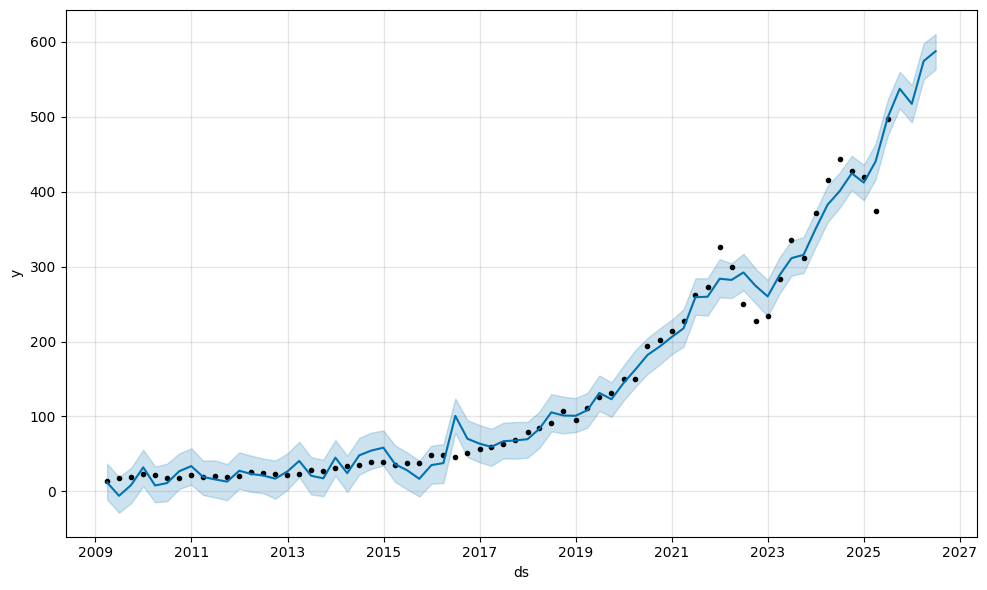

In [31]:
#5) Plot the results

figl = m.plot(forecast)
figl.show()

In [32]:
correlations = data.corr()
correlations

,ds,y,revenue_musd,net_income_musd,assets_liabilities_ratio,share_holder_equity_musd,gdp_growth,interest_rate
ds,1.000000,0.900988,0.931315,0.842774,-0.284367,0.862584,0.268059,0.734807
y,0.900988,1.000000,0.982372,0.938972,0.036790,0.956634,0.209424,0.773279
revenue_musd,0.931315,0.982372,1.000000,0.935603,0.015026,0.968944,0.232185,0.802555
net_income_musd,0.842774,0.938972,0.935603,1.000000,0.098027,0.909135,0.198542,0.732138
assets_liabilities_ratio,-0.284367,0.036790,0.015026,0.098027,1.000000,0.175554,-0.049754,0.030631
share_holder_equity_musd,0.862584,0.956634,0.968944,0.909135,0.175554,1.000000,0.201364,0.817985
gdp_growth,0.268059,0.209424,0.232185,0.198542,-0.049754,0.201364,1.000000,0.138662
interest_rate,0.734807,0.773279,0.802555,0.732138,0.030631,0.817985,0.138662,1.000000


/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_10258/89357559.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figl_bt.show()


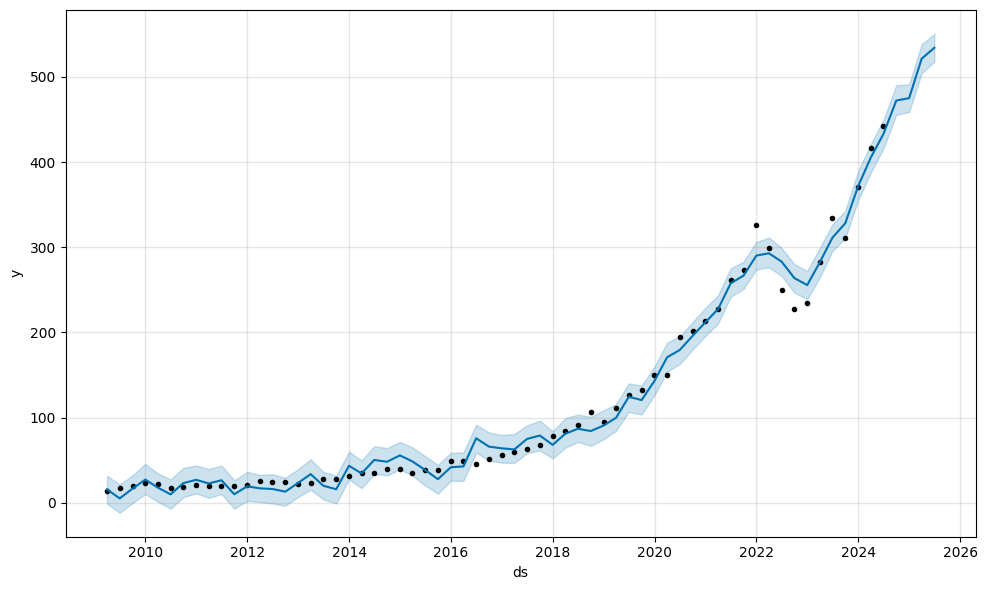

In [33]:
# 5) Plot the results for backtesting data

figl_bt = m_bt.plot(forecast_bt)
figl_bt.show()

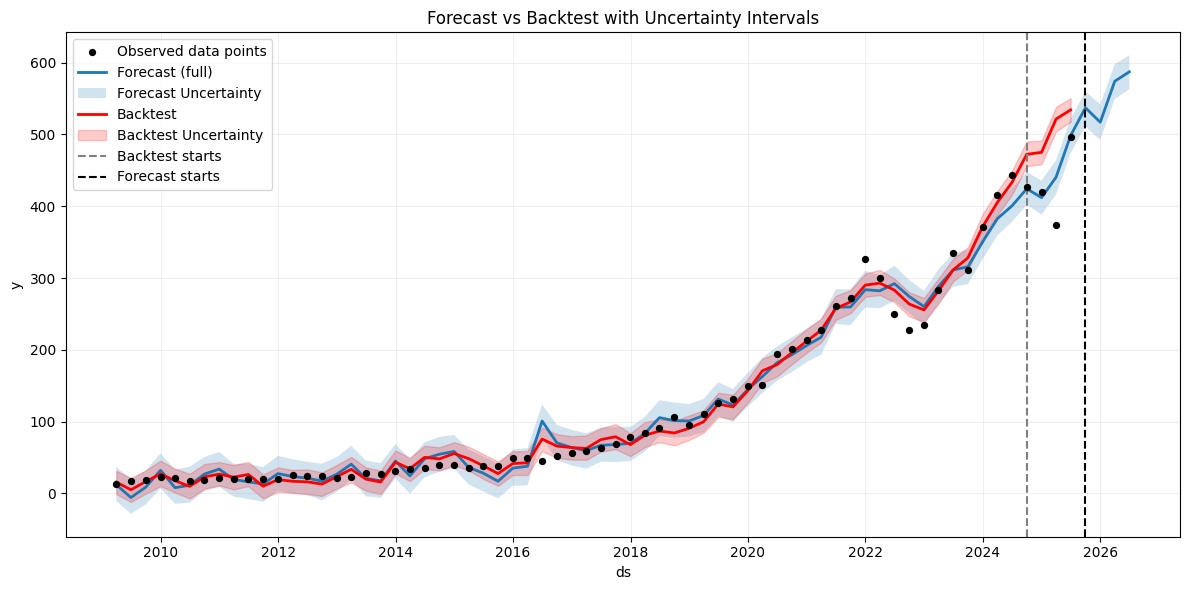

In [34]:
#6) Plot the results together

# --- Ensure datetime dtype
results['ds'] = pd.to_datetime(results['ds'])
results_bt['ds'] = pd.to_datetime(results_bt['ds'])

# --- Find split dates
bt_split   = results_bt.loc[results_bt['is_future'], 'ds'].min()   # ~2024-09-30
full_split = results.loc[results['is_future'], 'ds'].min()         # ~2025-09-30

fig, ax = plt.subplots(figsize=(12,6))

# Actuals (dots) from full dataset
mask_actual = ~results['is_future']
ax.scatter(results.loc[mask_actual, 'ds'],
           results.loc[mask_actual, 'y'],
           s=18, label='Observed data points', zorder=3, color='k')

# Forecast (full) line + CI
ax.plot(results['ds'], results['yhat'], label='Forecast (full)', linewidth=2)
ax.fill_between(results['ds'], results['yhat_lower'], results['yhat_upper'],
                alpha=0.2, label='Forecast Uncertainty')

# Backtest line + CI
ax.plot(results_bt['ds'], results_bt['yhat'], label='Backtest', linewidth=2, color='red')
ax.fill_between(results_bt['ds'], results_bt['yhat_lower'], results_bt['yhat_upper'],
                alpha=0.2, label='Backtest Uncertainty', color='red')

# --- Vertical split lines
if pd.notna(bt_split):
    ax.axvline(bt_split, linestyle='--', linewidth=1.5, color='gray')
    # Dummy handle just for legend
    ax.plot([], [], linestyle='--', linewidth=1.5, color='gray', label='Backtest starts')

if pd.notna(full_split):
    ax.axvline(full_split, linestyle='--', linewidth=1.5, color='black')
    # Dummy handle just for legend
    ax.plot([], [], linestyle='--', linewidth=1.5, color='black', label='Forecast starts')

# Cosmetics
ax.set_title('Forecast vs Backtest with Uncertainty Intervals')
ax.set_xlabel('ds'); ax.set_ylabel('y')
# Deduplicate legend labels
handles, labels = ax.get_legend_handles_labels()
uniq = dict(zip(labels, handles))
ax.legend(uniq.values(), uniq.keys(), loc='upper left')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()